In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sys, os
import importlib
import numpy as np

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..', '..')) 
print("Project root:",project_root)
sys.path.append(project_root)

configs_parent = os.path.join(project_root, "src/mosaic")
sys.path.append(configs_parent)

dataset_name = "5MeO_naturalistic"  # Define target name
module_path = f"src.mosaic.configs.{dataset_name}"
config_module = importlib.import_module(module_path) #dynamically load the module 
config = config_module.config


results_dir = os.path.join(project_root, f'RESULTS/optuna/{dataset_name}')

transformer_model = "Qwen/Qwen3-Embedding-0.6B" #or config.transformer_model
sanitized_model_name = transformer_model.replace('/', '_') #name of the transformer model with '/' replaced by '_'
file_path = os.path.join(results_dir, f'OPTUNA_{sanitized_model_name}_results.csv')
df = pd.read_csv(file_path)





Project root: /raid/home/rbeaute/Projects/MOSAIC


/home/rbeaute/Projects/MOSAIC/.mosaicvenv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


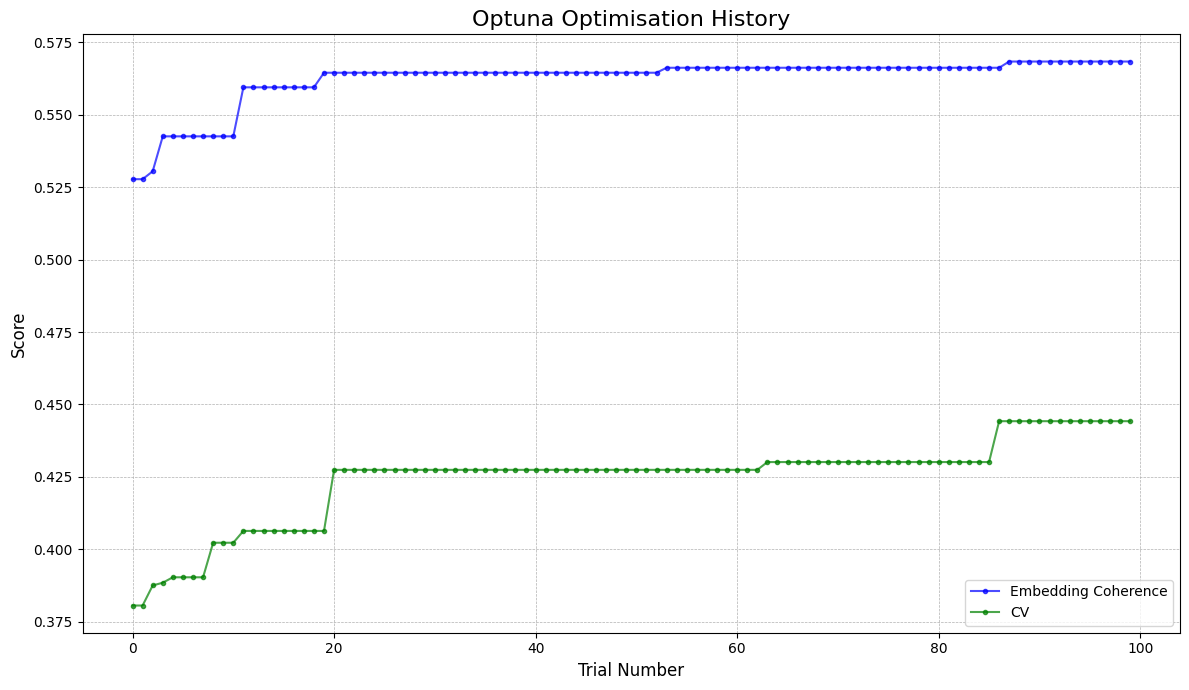

In [3]:
file_path = os.path.join(results_dir, f'OPTUNA_{sanitized_model_name}_results.csv')

df = pd.read_csv(file_path)

df['objective_embed_coherence'] = df['embedding_coherence'].cummax()
df['objective_cv'] = df['objective_cv'].cummax()

plt.figure(figsize=(12, 7))
plt.plot(df['trial_number'], df['objective_embed_coherence'], marker='.', linestyle='-', color='b', alpha=0.7, label='Embedding Coherence')
plt.plot(df['trial_number'], df['objective_cv'], marker='.', linestyle='-', color='g', alpha=0.7, label='CV')

plt.title('Optuna Optimisation History', fontsize=16)
plt.xlabel('Trial Number', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.tight_layout()

plt.show()

In [4]:
#print the best combination of hyperparameters found
best_trial = df.loc[df['embedding_coherence'].idxmax()]
print("Best Trial:")
print(f"Trial Number: {int(best_trial['trial_number'])}")
print(f"Best Embedding Coherence: {best_trial['embedding_coherence']}")
print(f"CV Score: {best_trial['objective_cv']}")
print(f"Hyperparameters: n_components={best_trial['n_components']}, n_neighbors={best_trial['n_neighbors']}, min_dist={best_trial['min_dist']}, min_cluster_size={best_trial['min_cluster_size']}, min_samples={best_trial['min_samples']}")
print(f"Number of topic for this trial: {int(best_trial['n_topics'])}")

Best Trial:
Trial Number: 87
Best Embedding Coherence: 0.5683684349060059
CV Score: 0.4442369985319105
Hyperparameters: n_components=12.0, n_neighbors=24.0, min_dist=0.02, min_cluster_size=25.0, min_samples=32.0
Number of topic for this trial: 33


Found 1 solutions on the Pareto Front:

 trial_number  embedding_coherence  objective_cv  n_topics
           87             0.568368      0.444237        33


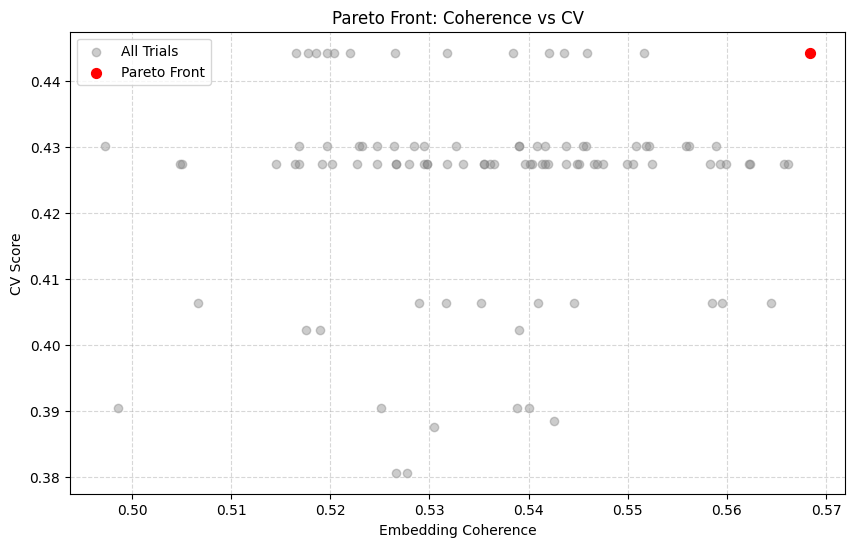

In [7]:
from src.mosaic.utils import get_pareto_front
pareto_solution = get_pareto_front(df, 'embedding_coherence', 'objective_cv')